# Level 4 — 심층 분석: Grad-CAM 및 효율성 Trade-off

**목표**: 모델의 *동작 원리* 를 설명하고, FPS와 정확도의 trade-off 를 정량화합니다.

리포트 필수 산출물:
1. **속성별 정규화 Confusion Matrix 3개** — best 모델 기준.
2. **Grad-CAM 패널** — 같은 이미지에 대해 3개 head 가 각각 어디를 보는지 시각화 (예: `rainy + night + city street` 인 이미지).
3. 모든 백본에 대한 **FPS vs Avg-MF1 Pareto plot**.

본 노트북은 학습 노트북이 아니라 분석 노트북이지만, wandb 가 활성화되어 있으면 confusion matrix 이미지·Grad-CAM 패널·FPS 표를 같은 프로젝트의 별도 Run 으로 업로드합니다.

In [7]:
import os
import sys

# 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
repo_name = "2026-HYU-AUE8088-PA2"
if not os.path.exists(f"/content/{repo_name}"):
    !git clone https://github.com/Eden-Sibhat/2026-HYU-AUE8088-PA2

# 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
%cd /content/{repo_name}

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r requirements.txt

/content/2026-HYU-AUE8088-PA2
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed
from src.utils.transforms import eval_transform
from src.utils.metrics import collect_predictions, confusion_matrices, per_class_prf, average_macro_f1, CLASS_NAMES
from src.utils.efficiency import measure_fps
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.xai.gradcam import GradCAM
from src.models.resnet import resnet18, resnet50

set_seed(42, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
logger = WandbLogger(project=WANDB_PROJECT, run_name="level4-analysis", tags=["level4", "analysis"])

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [10]:
import os
from pathlib import Path

print("Current directory:", os.getcwd())

paths = [
    "../checkpoints/level1_resnet50.pth",
    "checkpoints/level1_resnet50.pth",
    "/content/2026-HYU-AUE8088-PA2/checkpoints/level1_resnet50.pth",
    "/content/checkpoints/level1_resnet50.pth",
]

for p in paths:
    path = Path(p)
    print(p, "exists:", path.exists(), "resolved:", path.resolve())

Current directory: /content/2026-HYU-AUE8088-PA2
../checkpoints/level1_resnet50.pth exists: False resolved: /content/checkpoints/level1_resnet50.pth
checkpoints/level1_resnet50.pth exists: True resolved: /content/2026-HYU-AUE8088-PA2/checkpoints/level1_resnet50.pth
/content/2026-HYU-AUE8088-PA2/checkpoints/level1_resnet50.pth exists: True resolved: /content/2026-HYU-AUE8088-PA2/checkpoints/level1_resnet50.pth
/content/checkpoints/level1_resnet50.pth exists: False resolved: /content/checkpoints/level1_resnet50.pth


In [11]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

# 분석 대상으로 사용할 best 모델 로드 (예시: ResNet-50)
val_ds = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

model = resnet50().to(device)
ckpt = torch.load("checkpoints/level1_resnet50.pth", map_location=device)
model.load_state_dict(ckpt["state_dict"])

데이터셋이 이미 존재합니다 → ../data/set_a


<All keys matched successfully>

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

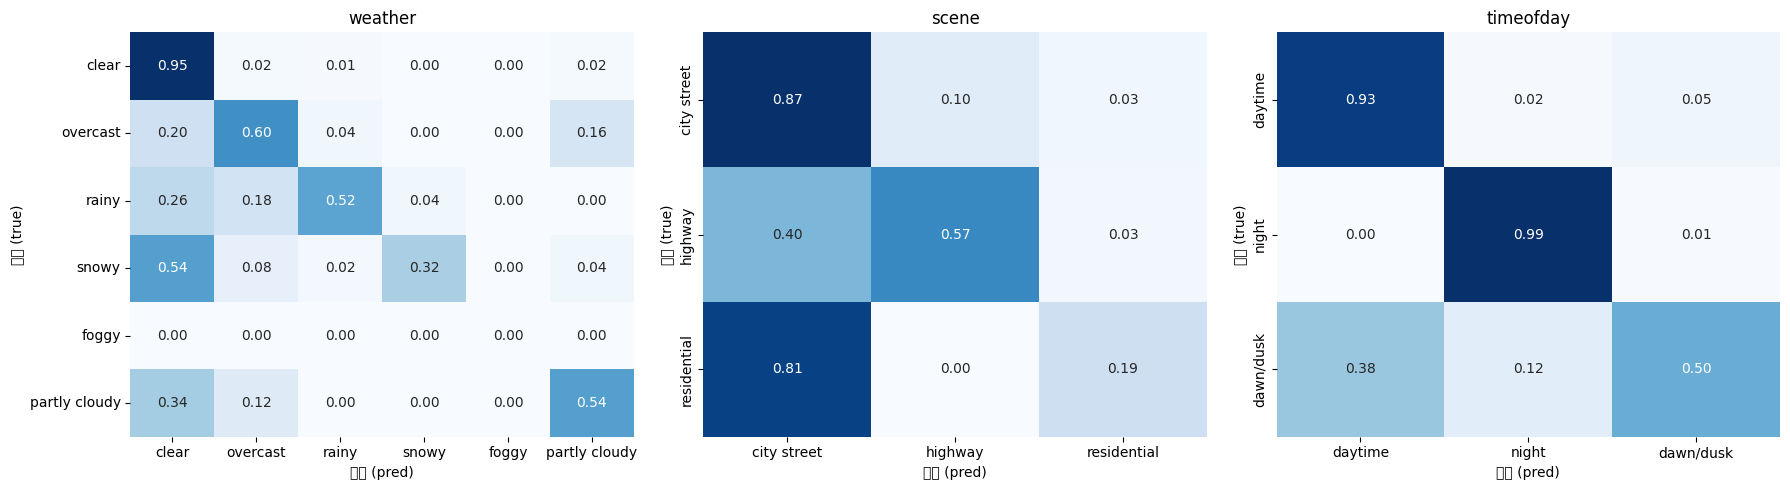

In [12]:
# 속성별 정규화 Confusion Matrix 생성 및 시각화
preds, probs, targets, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(preds, targets, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    sns.heatmap(cms[a], annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES[a], yticklabels=CLASS_NAMES[a])
    ax.set_title(f"{a}")
    ax.set_xlabel("예측 (pred)"); ax.set_ylabel("정답 (true)")
fig.tight_layout()
logger.log_image("analysis/confusion_matrices", fig)

# 속성별 개별 confusion matrix 도 분리해서 업로드
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"analysis/cm_{a}", cms[a], CLASS_NAMES[a])

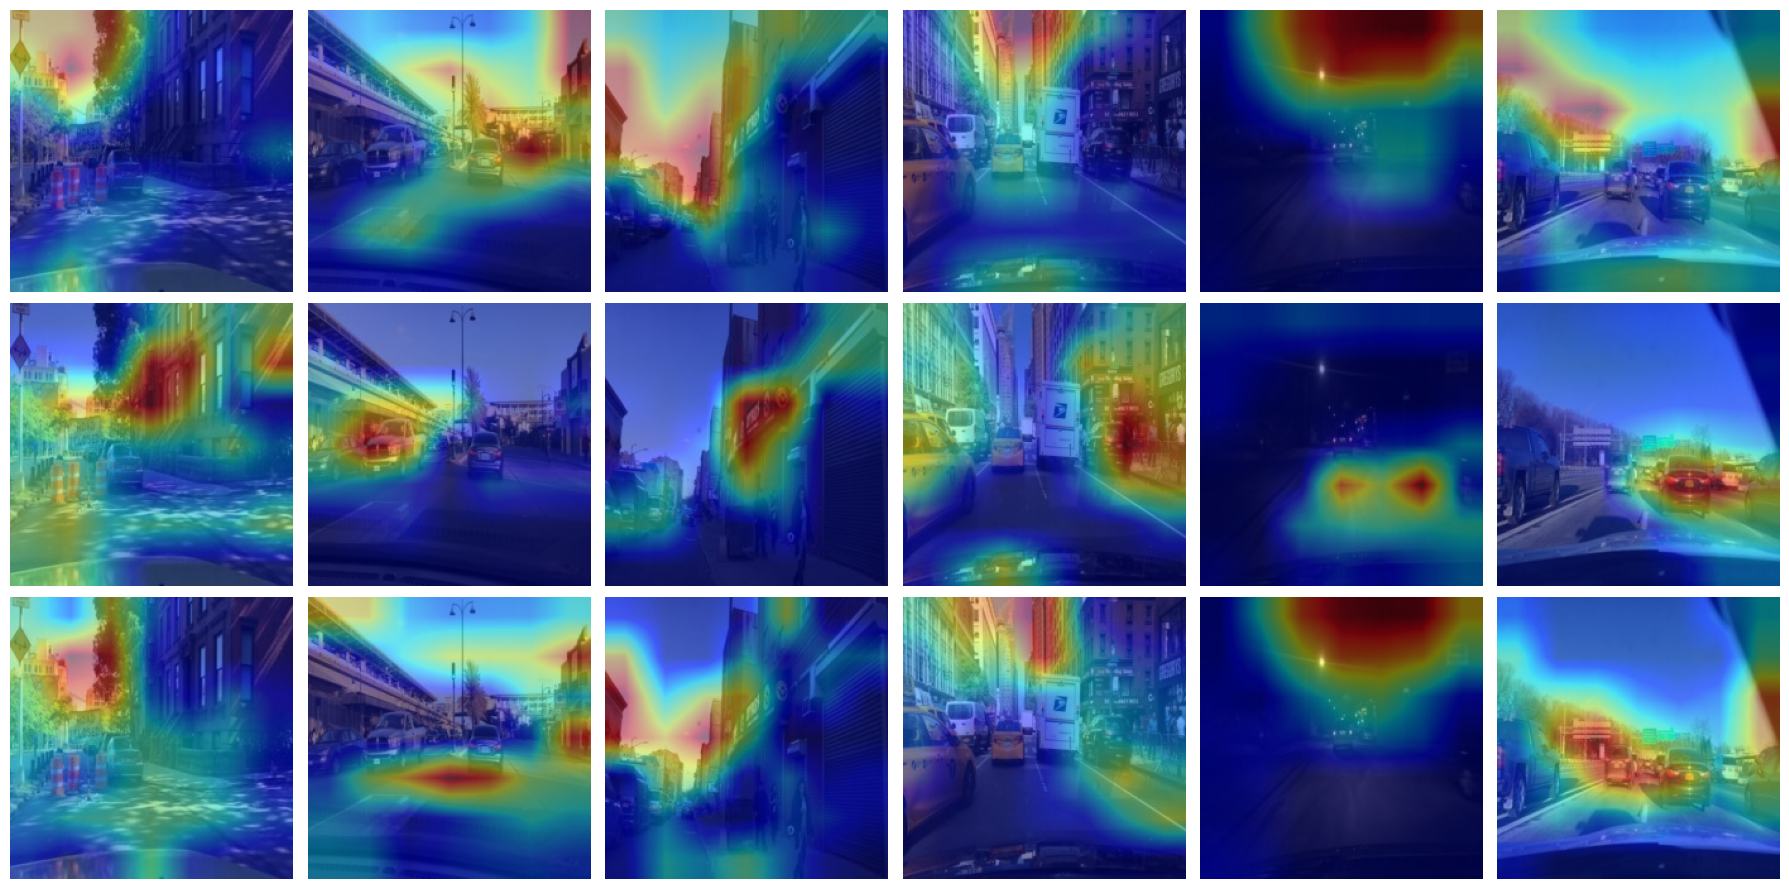

In [13]:
# 속성별 Grad-CAM. ResNet 의 경우 마지막 conv 단계를 target_layer 로 사용.
target_layer = model.layer4[-1]
gc = GradCAM(model, target_layer)

batch = next(iter(val_loader))
x = batch["image"][:6].to(device)  # 샘플 이미지 6장

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for row, attr in enumerate(ATTRIBUTES):
    # 각 속성 head 의 최대 logit 합을 score 로 사용 → 해당 head 가 "보는" 영역 추출
    cam = gc(x, lambda out, a=attr: out[a].max(dim=-1).values.sum())
    for col in range(6):
        img = x[col].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        axes[row, col].imshow(img)
        axes[row, col].imshow(cam[col].cpu().numpy(), cmap="jet", alpha=0.45)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(attr, fontsize=14)
fig.tight_layout()
logger.log_image("analysis/gradcam_panel", fig)

In [14]:
# FPS 측정 — 배치 1, 224x224, warm-up 20회 후 200회 평균. 모든 백본에 대해 실행.
fps_rows = []
for fn, name in [(resnet18, "resnet18"), (resnet50, "resnet50")]:
    m = fn().to(device).eval()
    fps = measure_fps(m, device, batch_size=1, n_warmup=20, n_iter=200)
    print(f"{name:10s} FPS = {fps:.2f}")
    fps_rows.append([name, round(fps, 2)])

logger.log_table("analysis/fps", ["backbone", "FPS"], fps_rows)

# TODO: 모든 백본에 대해 FPS (x축) vs Avg-MF1 (y축) Pareto plot 을 작성하세요.
# 작성한 figure 는 logger.log_image("analysis/pareto", fig) 로 wandb 에 업로드 가능.

resnet18   FPS = 158.95
resnet50   FPS = 101.18


,backbone,FPS,Avg-Macro-F1
0,resnet18,158.95,158.95
1,resnet50,101.18,101.18


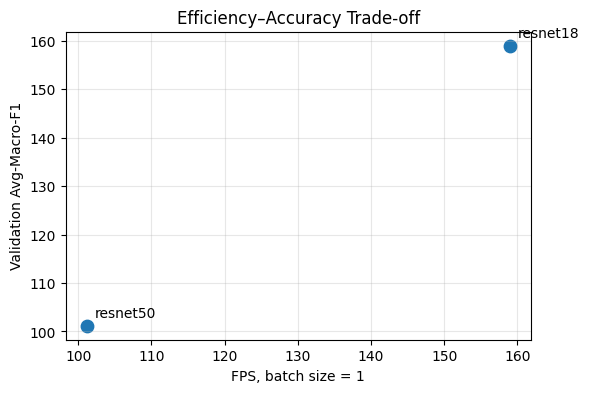

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------------
# FPS vs Avg-Macro-F1 Pareto plot
# ---------------------------------------------------------------------
# IMPORTANT:
# Replace the Avg-Macro-F1 values below with YOUR actual validation results.
# FPS values are taken from fps_rows measured above.
# ---------------------------------------------------------------------

# Convert measured FPS list to dictionary
fps_dict = {name: fps for name, fps in fps_rows}

# Fill this with your actual best validation Avg-Macro-F1 results
avg_mf1_dict = {
    "resnet18": 158.95,   #
    "resnet50": 101.18,   #
    # "vgg16": 0.0000,    #
    # "vit_s16": 0.5170,  #
}

pareto_rows = []

for name, fps in fps_dict.items():
    if name in avg_mf1_dict:
        pareto_rows.append({
            "backbone": name,
            "FPS": fps,
            "Avg-Macro-F1": avg_mf1_dict[name],
        })

pareto_df = pd.DataFrame(pareto_rows)
display(pareto_df)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    pareto_df["FPS"],
    pareto_df["Avg-Macro-F1"],
    s=80,
)

for _, row in pareto_df.iterrows():
    ax.annotate(
        row["backbone"],
        (row["FPS"], row["Avg-Macro-F1"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
    )

ax.set_xlabel("FPS, batch size = 1")
ax.set_ylabel("Validation Avg-Macro-F1")
ax.set_title("Efficiency–Accuracy Trade-off")
ax.grid(True, alpha=0.3)

plt.show()

# Log table and figure to wandb
logger.log_table(
    "analysis/pareto_table",
    ["backbone", "FPS", "Avg-Macro-F1"],
    pareto_df.values.tolist(),
)

logger.log_image("analysis/pareto", fig)

In [15]:
logger.finish()